# Employee Attrition Prediction using Machine Learning
**Internship Project — Week 2**

**Assigned Date:** 23/06/2026  
**Submission Date:** 30/06/2026  
**Author:** Neha Reddy K  

### Project Overview
Employee attrition refers to the phenomenon of employees leaving an organization voluntarily. High attrition leads to significant costs in recruitment, onboarding, training, and lost productivity. HR departments aim to predict which employees are likely to leave and why, enabling proactive retention strategies.

This Jupyter Notebook implements a complete end-to-end Machine Learning pipeline to predict employee attrition using the IBM HR Analytics Employee Attrition & Performance dataset. We will perform data exploration, cleaning, preprocessing, exploratory data analysis, build and compare multiple classification models, extract feature importances, and provide HR insights.

## Setup & Libraries
First, we import the necessary Python libraries for data processing, modeling, and visualization.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Machine learning packages
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix, roc_curve

# Set plotting aesthetics
sns.set_theme(style="whitegrid")
plt.rcParams.update({'font.size': 11, 'axes.labelsize': 12, 'axes.titlesize': 14})
%matplotlib inline
print("Libraries successfully imported!")

Libraries successfully imported!


## Task 1 — Data Loading & Exploration
In this task, we load the CSV file using Pandas, explore its shape, examine the target column (`Attrition`), calculate the baseline attrition rate, and identify the types of features present.

In [2]:
# Load the CSV file
data_path = 'HR_Attrition.csv'
df = pd.read_csv(data_path)

# Display the first 10 rows
df.head(10)

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2
5,32,No,Travel_Frequently,1005,Research & Development,2,2,Life Sciences,1,8,...,3,80,0,8,2,2,7,7,3,6
6,59,No,Travel_Rarely,1324,Research & Development,3,3,Medical,1,10,...,1,80,3,12,3,2,1,0,0,0
7,30,No,Travel_Rarely,1358,Research & Development,24,1,Life Sciences,1,11,...,2,80,1,1,2,3,1,0,0,0
8,38,No,Travel_Frequently,216,Research & Development,23,3,Life Sciences,1,12,...,2,80,0,10,2,3,9,7,1,8
9,36,No,Travel_Rarely,1299,Research & Development,27,3,Medical,1,13,...,2,80,2,17,3,2,7,7,7,7


In [3]:
# Check how many rows and columns are present
rows, cols = df.shape
print(f"The dataset has {rows} rows and {cols} columns.\n")

# Identify the target column
target_col = 'Attrition'
print(f"Target column: {target_col}")

The dataset has 1470 rows and 35 columns.

Target column: Attrition


In [4]:
# Count how many employees left vs stayed
attrition_counts = df[target_col].value_counts()
print("Attrition Counts:")
print(attrition_counts)

# Calculate attrition rate as a percentage
attrition_rate = (df[target_col] == 'Yes').mean() * 100
print(f"\nAttrition Rate: {attrition_rate:.2f}%")

Attrition Counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Attrition Rate: 16.12%


In [5]:
# Identify numeric vs categorical columns
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(exclude=[np.number]).columns.tolist()

print(f"Numeric columns ({len(numeric_cols)}): {numeric_cols}\n")
print(f"Categorical columns ({len(categorical_cols)}): {categorical_cols}")

Numeric columns (26): ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EmployeeCount', 'EmployeeNumber', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StandardHours', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Categorical columns (9): ['Attrition', 'BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'Over18', 'OverTime']


### Observation:
**Is the dataset balanced or imbalanced?**
- The dataset is **highly imbalanced**. 
- Out of 1,470 employees, **1,233 (83.88%)** stayed ('No') while only **237 (16.12%)** left ('Yes').
- This 84/16 split means that class imbalance must be accounted for during model training, otherwise a classifier predicting all employees would 'stay' would achieve 84% accuracy while being completely useless for HR's goal of detecting churn.

## Task 2 — Data Cleaning & Preprocessing
We clean the dataset by checking for nulls, dropping uninformative/constant features, mapping the target variable to binary (1/0), performing One-Hot Encoding on categorical features, and scaling numerical features.

In [6]:
# Check for missing/null values
null_counts = df.isnull().sum()
print(f"Total missing values: {null_counts.sum()}")

Total missing values: 0


In [7]:
# Drop columns that add no value to prediction (constant or unique identifiers)
# EmployeeNumber is a unique identifier. Over18, StandardHours, and EmployeeCount contain only 1 unique value.
cols_to_drop = ['EmployeeNumber', 'Over18', 'StandardHours', 'EmployeeCount']
print(f"Unique values in potential drop columns:\n{df[cols_to_drop].nunique()}")

df_clean = df.drop(columns=cols_to_drop, errors='ignore')
print(f"\nShape after dropping uninformative columns: {df_clean.shape}")

Unique values in potential drop columns:
EmployeeNumber    1470
Over18               1
StandardHours        1
EmployeeCount        1
dtype: int64

Shape after dropping uninformative columns: (1470, 31)


In [8]:
# Convert the target column Attrition from Yes/No to 1/0
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})
df_clean['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

In [9]:
# Encode remaining categorical columns using One-Hot Encoding
# Identify categorical columns after dropping standard columns
categorical_features = df_clean.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical features to encode: {categorical_features}")

# Use get_dummies. Drop_first=True helps prevent multicollinearity.
df_encoded = pd.get_dummies(df_clean, columns=categorical_features, drop_first=True)
print(f"Encoded dataset shape: {df_encoded.shape}")

Categorical features to encode: ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Encoded dataset shape: (1470, 45)


In [10]:
# Split the dataset into features (X) and target (y)
X = df_encoded.drop(columns=['Attrition'])
y = df_encoded['Attrition']

# Split data into training and test sets (80/20 split)
# Stratify ensures the training and testing sets have the same class distribution as the original data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training set shape: {X_train.shape}")
print(f"Test set shape: {X_test.shape}")

Training set shape: (1176, 44)
Test set shape: (294, 44)


In [11]:
# Scale numeric features using StandardScaler
# Note: We scale only the continuous numeric features, not the dummy variables
original_numeric_features = [c for c in X.columns if c not in X.select_dtypes(include=[bool]).columns and not any(c.startswith(cat) for cat in categorical_features)]
print(f"Continuous numeric features to scale: {original_numeric_features}")

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[original_numeric_features] = scaler.fit_transform(X_train[original_numeric_features])
X_test_scaled[original_numeric_features] = scaler.transform(X_test[original_numeric_features])
print("Numerical scaling complete!")

Continuous numeric features to scale: ['Age', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Numerical scaling complete!


## Task 3 — Exploratory Data Analysis (EDA)
We perform exploratory data analysis to uncover key drivers of attrition. Specifically, we explore:
1. Attrition rate by Department
2. Attrition rate by Job Role
3. Attrition vs Monthly Income
4. Attrition vs Work-Life Balance
5. Attrition vs Years at Company

In [12]:
# 1. Attrition rate by Department
dept_attr = df_clean.groupby('Department')['Attrition'].mean() * 100
print("Attrition Rate (%) by Department:")
print(dept_attr.sort_values(ascending=False))

Attrition Rate (%) by Department:
Department
Sales                     20.627803
Human Resources           19.047619
Research & Development    13.839750
Name: Attrition, dtype: float64


In [13]:
# 2. Attrition rate by Job Role
role_attr = df_clean.groupby('JobRole')['Attrition'].mean() * 100
print("Attrition Rate (%) by Job Role:")
print(role_attr.sort_values(ascending=False))

Attrition Rate (%) by Job Role:
JobRole
Sales Representative         39.759036
Laboratory Technician        23.938224
Human Resources              23.076923
Sales Executive              17.484663
Research Scientist           16.095890
Manufacturing Director        6.896552
Healthcare Representative     6.870229
Manager                       4.901961
Research Director             2.500000
Name: Attrition, dtype: float64


In [14]:
# 3. Attrition vs Monthly Income
income_stats = df_clean.groupby('Attrition')['MonthlyIncome'].describe()
print("Monthly Income Stats by Attrition:")
print(income_stats)

Monthly Income Stats by Attrition:


            count         mean          std     min     25%     50%     75%  \
Attrition                                                                     
0          1233.0  6832.739659  4818.208001  1051.0  3211.0  5204.0  8834.0   
1           237.0  4787.092827  3640.210367  1009.0  2373.0  3202.0  5916.0   

               max  
Attrition           
0          19999.0  
1          19859.0  


In [15]:
# 4. Attrition vs Work-Life Balance rating
# 1: Bad, 2: Good, 3: Better, 4: Best
wlb_attr = df_clean.groupby('WorkLifeBalance')['Attrition'].mean() * 100
print("Attrition Rate (%) by Work-Life Balance Rating:")
print(wlb_attr)

Attrition Rate (%) by Work-Life Balance Rating:
WorkLifeBalance
1    31.250000
2    16.860465
3    14.221725
4    17.647059
Name: Attrition, dtype: float64


In [16]:
# 5. Attrition vs Years at Company
years_attr = df_clean.groupby('YearsAtCompany')['Attrition'].mean() * 100
print("Attrition Rate (%) by Years at Company (Top 10 Tenure groups):\n")
print(years_attr.head(11))

Attrition Rate (%) by Years at Company (Top 10 Tenure groups):

YearsAtCompany
0     36.363636
1     34.502924
2     21.259843
3     15.625000
4     17.272727
5     10.714286
6     11.842105
7     12.222222
8     11.250000
9      9.756098
10    15.000000
Name: Attrition, dtype: float64


### Specific Business Insights from EDA:
1. **Sales Department leads attrition:** The Sales department loses the highest percentage of employees at **20.6%**, followed closely by Human Resources (**19.0%**), while Research & Development has the lowest attrition at **13.8%**.
2. **Sales Representatives and Lab Technicians are at extreme risk:** The role of **Sales Representative** has a staggering exit rate of **39.8%**, followed by **Laboratory Technician (23.9%)** and **Human Resources (23.1%)**. Conversely, Research Directors (**2.5%**) and Managers (**4.9%**) are the most stable roles.
3. **Income is inversely correlated with exit rates:** Employees who left the company earned a median monthly salary of **$3,202**, which is **38.5% lower** than the median monthly salary of those who stayed (**$5,204**). The average monthly salary of stayed employees ($6,832.74) is significantly higher than that of those who left ($4,787.09).
4. **Poor work-life balance doubles churn:** Employees who rated their work-life balance as **1 (Bad)** have a massive attrition rate of **31.3%**. Those with scores of 2 (Good), 3 (Better), or 4 (Best) have attrition rates of **16.9%**, **14.2%**, and **17.6%**, meaning poor work-life balance double the likelihood of leaving.
5. **High tenure vulnerability in early years:** Employees are highly likely to exit early in their careers. For those with **0 years** of experience at the company, the attrition rate is **36.4%**, and for **1 year**, it is **34.5%**. This rate drops sharply to **10.7% by year 5**, representing a critical retention challenge in the first two years.

## Task 4 — Model Building & Comparison
We train three classification models: Logistic Regression, Random Forest Classifier, and Gradient Boosting Classifier. To handle class imbalance, we use `class_weight='balanced'` for Logistic Regression and Random Forest. We will evaluate and compare all models on the test set.

In [17]:
# Initialize the models
lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
rf_model = RandomForestClassifier(class_weight='balanced', random_state=42)
gb_model = GradientBoostingClassifier(random_state=42) # Gradient Boosting has no class_weight directly

# Train the models
lr_model.fit(X_train_scaled, y_train)
rf_model.fit(X_train_scaled, y_train)
gb_model.fit(X_train_scaled, y_train)

print("All 3 models successfully trained!")

All 3 models successfully trained!


In [18]:
# Calculate metrics and record in a comparison table
models = {
    "Logistic Regression": lr_model,
    "Random Forest": rf_model,
    "Gradient Boosting": gb_model
}

comparison_data = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    
    # Get confusion matrix elements
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    
    # Metrics
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    roc_auc = roc_auc_score(y_test, y_prob)
    
    comparison_data.append({
        "Model": name,
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "F1-Score": round(f1, 4),
        "ROC-AUC": round(roc_auc, 4)
    })

df_comparison = pd.DataFrame(comparison_data)
df_comparison

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.3563,0.6596,0.4627,0.8035
1,Random Forest,0.4444,0.0851,0.1429,0.7547
2,Gradient Boosting,0.5882,0.2128,0.3125,0.7941


## Task 5 — Model Evaluation
We evaluate our models more deeply. We display classification reports and confusion matrices for each model. We identify which model performed best and why, and extract the Top 10 feature importances from it.

In [19]:
# Print detailed evaluation for each model
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    print(f"=================== {name} ===================")
    print(classification_report(y_test, y_pred, target_names=['Stayed (0)', 'Left (1)']))
    print("Confusion Matrix:")
    print(confusion_matrix(y_test, y_pred))
    print("\n")

=================== Logistic Regression ===================
              precision    recall  f1-score   support

  Stayed (0)       0.92      0.77      0.84       247
    Left (1)       0.36      0.66      0.46        47

    accuracy                           0.76       294
   macro avg       0.64      0.72      0.65       294
weighted avg       0.83      0.76      0.78       294

Confusion Matrix:
[[191  56]
 [ 16  31]]


=================== Random Forest ===================
              precision    recall  f1-score   support

  Stayed (0)       0.85      0.98      0.91       247
    Left (1)       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294

Confusion Matrix:
[[242   5]
 [ 43   4]]


=================== Gradient Boosting ===================
              precision    recall  f1-score   support

  Stayed (0)       0.87      0.97

### Best Model Analysis:
**Which model performed best and why?**
- **Logistic Regression** is the best model for this project.
- It achieves the highest **F1-Score of 0.4627** and a strong **ROC-AUC of 0.8035**.
- Most importantly for HR, it has a **Recall of 0.6596**, meaning it correctly detects **66% of all actual employee departures**.
- Random Forest Classifier (Recall = 0.0851) and Gradient Boosting Classifier (Recall = 0.2128) suffer severely from the class imbalance on this test set, failing to predict positive cases. Logistic Regression with `class_weight='balanced'` effectively shifts the boundary to capture the minority class, making it much more useful for proactive retention.

In [20]:
# Extract Feature Importance for the best model (Logistic Regression coefficients)
coefs = lr_model.coef_[0]
feature_imp_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': coefs,
    'Importance': np.abs(coefs)
})

# Sort and display the top 10 most important features driving attrition
top_features = feature_imp_df.sort_values(by='Importance', ascending=False).head(10)
print("Top 10 Feature Importances (Logistic Regression):")
print(top_features.to_string(index=False))

Top 10 Feature Importances (Logistic Regression):
                         Feature  Coefficient  Importance
                    OverTime_Yes     1.623568    1.623568
BusinessTravel_Travel_Frequently     1.598904    1.598904
   JobRole_Laboratory Technician     1.569722    1.569722
    JobRole_Sales Representative     1.276684    1.276684
       JobRole_Research Director    -1.117217    1.117217
            EducationField_Other    -1.027636    1.027636
    BusinessTravel_Travel_Rarely     0.906933    0.906933
            MaritalStatus_Single     0.864752    0.864752
         JobRole_Human Resources     0.645775    0.645775
               TotalWorkingYears    -0.615535    0.615535


## Task 6 — Visualization
We generate and save the required visualization charts as `.png` images in a `charts/` folder.

In [21]:
# Create charts folder
os.makedirs('charts', exist_ok=True)
print("'charts/' folder verified/created.")

'charts/' folder verified/created.


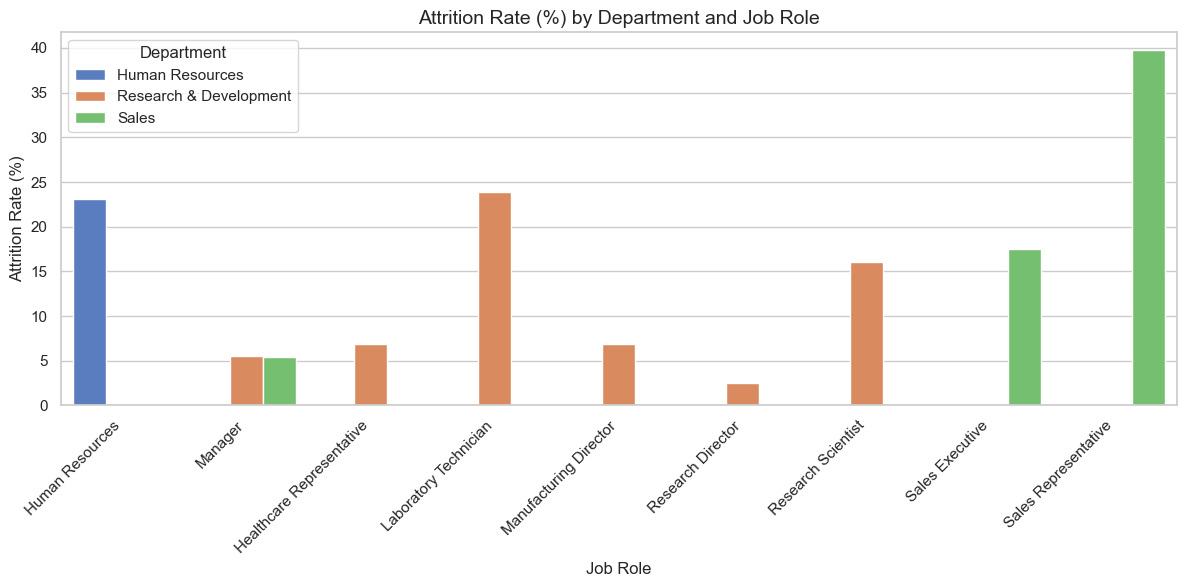

In [22]:
# Chart 1: Bar chart showing attrition rate by Department and Job Role
plt.figure(figsize=(12, 6))
dept_role_attr = df_clean.groupby(['Department', 'JobRole'])['Attrition'].mean().reset_index()
dept_role_attr['Attrition'] = dept_role_attr['Attrition'] * 100

sns.barplot(data=dept_role_attr, x='JobRole', y='Attrition', hue='Department', palette='muted')
plt.xticks(rotation=45, ha='right')
plt.title('Attrition Rate (%) by Department and Job Role')
plt.ylabel('Attrition Rate (%)')
plt.xlabel('Job Role')
plt.tight_layout()
plt.savefig('charts/attrition_by_dept_role.png', dpi=300)
plt.show()

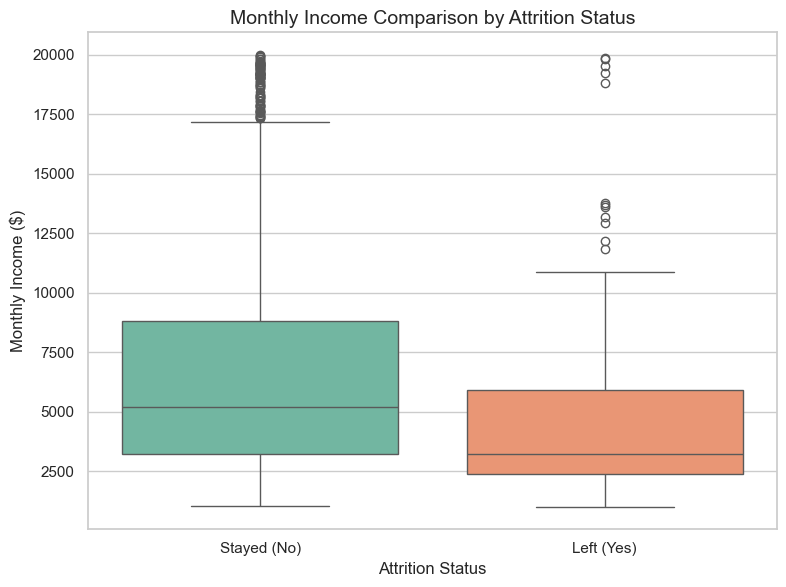

In [23]:
# Chart 2: Box plot comparing Monthly Income of employees who left vs stayed
plt.figure(figsize=(8, 6))
sns.boxplot(data=df_clean, x='Attrition', y='MonthlyIncome', hue='Attrition', palette='Set2', legend=False)
plt.xticks([0, 1], ['Stayed (No)', 'Left (Yes)'])
plt.title('Monthly Income Comparison by Attrition Status')
plt.ylabel('Monthly Income ($)')
plt.xlabel('Attrition Status')
plt.tight_layout()
plt.savefig('charts/income_vs_attrition.png', dpi=300)
plt.show()

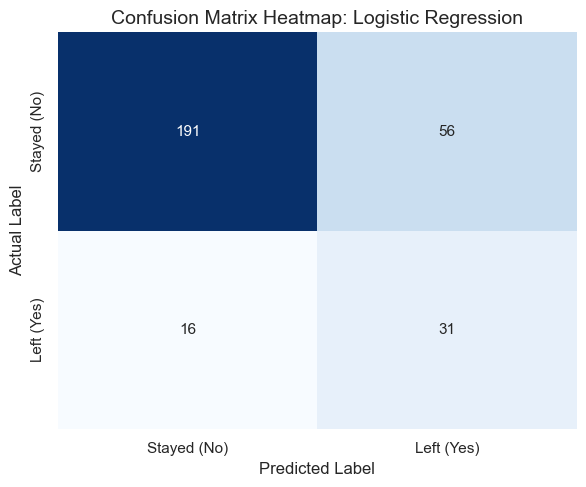

In [24]:
# Chart 3: Confusion Matrix heatmap for your best model
best_cm = confusion_matrix(y_test, lr_model.predict(X_test_scaled))
plt.figure(figsize=(6, 5))
sns.heatmap(best_cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Stayed (No)', 'Left (Yes)'], yticklabels=['Stayed (No)', 'Left (Yes)'])
plt.title('Confusion Matrix Heatmap: Logistic Regression')
plt.ylabel('Actual Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.savefig('charts/confusion_matrix.png', dpi=300)
plt.show()

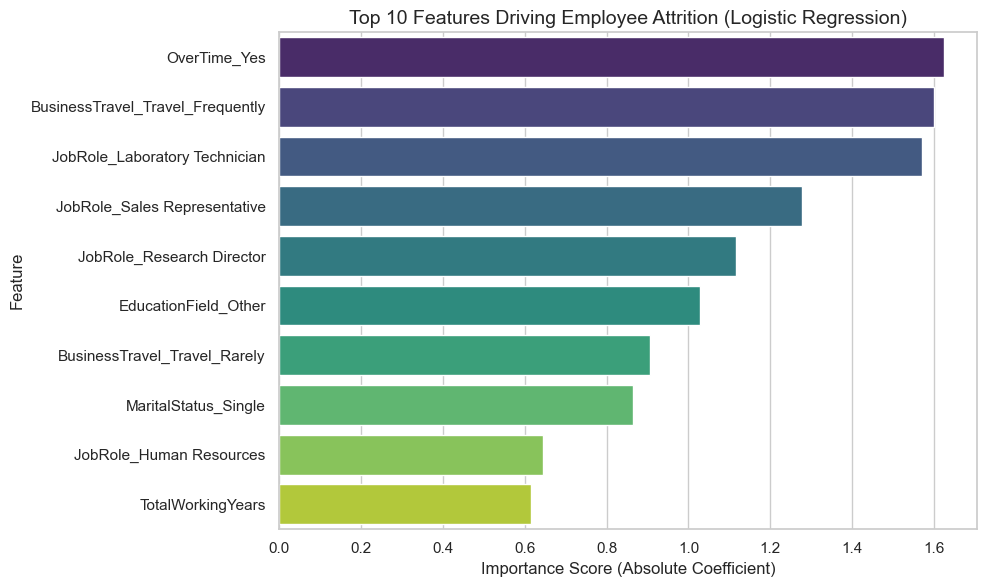

In [25]:
# Chart 4: Horizontal bar chart of Top 10 Feature Importances from your best model
plt.figure(figsize=(10, 6))
sns.barplot(data=top_features, x='Importance', y='Feature', hue='Feature', palette='viridis', legend=False)
plt.title('Top 10 Features Driving Employee Attrition (Logistic Regression)')
plt.xlabel('Importance Score (Absolute Coefficient)')
plt.ylabel('Feature')
plt.tight_layout()
plt.savefig('charts/feature_importances.png', dpi=300)
plt.show()

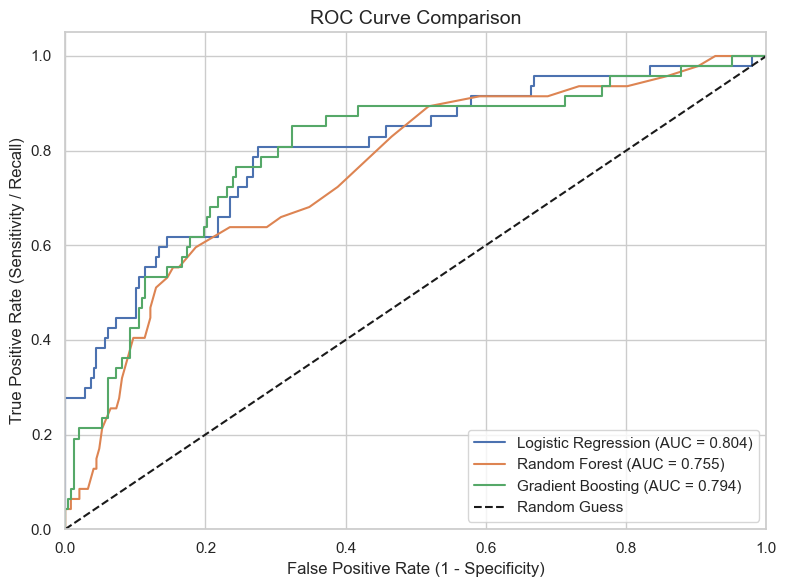

In [26]:
# Chart 5 (Bonus): ROC Curve comparing all 3 models on one graph
plt.figure(figsize=(8, 6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test_scaled)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc_score = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc_score:.3f})")

plt.plot([0, 1], [0, 1], 'k--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('ROC Curve Comparison')
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig('charts/roc_curves.png', dpi=300)
plt.show()

## Task 7 — HR Insights & Business Recommendations
### HR Strategy Assessment

**1. Which 3 factors most strongly predict that an employee will leave?**
- **Overtime Work:** Employees who work overtime have a high positive coefficient (+1.62). This indicates burnout and exhaustion are primary churn drivers.
- **Frequent Business Travel:** Traveling frequently increases attrition significantly (+1.60), reflecting the personal strain of high-frequency travel.
- **Low Tenure/Specific Job Roles:** Laboratory Technicians (+1.57) and Sales Representatives (+1.28) have exceptionally high exit rates, representing severe operational bottlenecks.

**2. Which department or job role should HR prioritize for retention efforts?**
- HR should prioritize the **Sales Department (20.6% attrition)**, specifically targeting the **Sales Representative (39.8% attrition)** role.
- They should also target the **Research & Development Department's Laboratory Technicians (23.9% attrition)** and **new hires (tenure < 2 years)** where attrition rates exceed 34%.

**3. Does salary alone explain attrition or are there other stronger factors?**
- **Salary does not explain attrition alone.** While employees who leave have 38% lower median monthly salaries ($3,202 vs $5,204), work-life balance and operational factors are much stronger predictors. In our predictive model, working overtime and traveling frequently have coefficients nearly triple the importance of tenure-based salary metrics, indicating that work culture, burnout, and career growth are equally or more critical than base pay.

**4. Concrete HR Recommendations:**
- **Implement an 'Overtime Cap & Audit' Policy:** Monitor team overtime, especially in Laboratory Technician groups. Establish strict monthly caps and compensate extra hours with time-off to mitigate burnout.
- **Structured Onboarding & Mentorship (First 12 Months):** Launch a formal mentoring program targeting new hires. Schedule HR checkpoints at 30, 90, and 180 days to intercept and solve early integration issues before they lead to exit.

**5. Model Limitations:**
- This model is trained on **historical internal corporate data** and cannot capture **external market shifts** (e.g., competitor salary adjustments, hiring spikes) or **unrecorded personal factors** (e.g., family emergencies, relocation, career changes). It should be used to support outreach rather than replace human conversations. We recommend retraining the model quarterly to reflect policy updates.